# 05 — Model Evaluation

Evaluates the trained CNN on the held-out test set:
classification report, confusion matrix, ROC curve, confidence distribution.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_curve, auc
)

from src.cnn_classifier import CNNClassifier

SPLIT_DIR  = '../data/processed/train_test_split'
MODEL_PATH = '../models/cnn_model.keras'
LABEL_NAMES = ['Transportation', 'Conversation']

## 1. Load model and test data

In [2]:
clf = CNNClassifier().load(MODEL_PATH)
print('CNN model loaded.')

X_test = np.load(os.path.join(SPLIT_DIR, 'X_test.npy'))
y_test = np.load(os.path.join(SPLIT_DIR, 'y_test.npy'))

if X_test.ndim == 3:
    X_test = X_test[..., np.newaxis]

print(f'Test set: {X_test.shape}  Transportation: {(y_test==0).sum()}  Conversation: {(y_test==1).sum()}')

CNN model loaded.
Test set: (1020, 128, 173, 1)  Transportation: 658  Conversation: 362


## 2. Classification report

In [3]:
y_pred  = clf.predict(X_test)
y_proba = clf.predict_proba(X_test)  # (N, 2): [:,0]=P(transport), [:,1]=P(conv)

print(classification_report(y_test, y_pred, target_names=LABEL_NAMES))

                precision    recall  f1-score   support

Transportation       1.00      1.00      1.00       658
  Conversation       0.99      1.00      0.99       362

      accuracy                           1.00      1020
     macro avg       1.00      1.00      1.00      1020
  weighted avg       1.00      1.00      1.00      1020



## 3. Confusion matrix

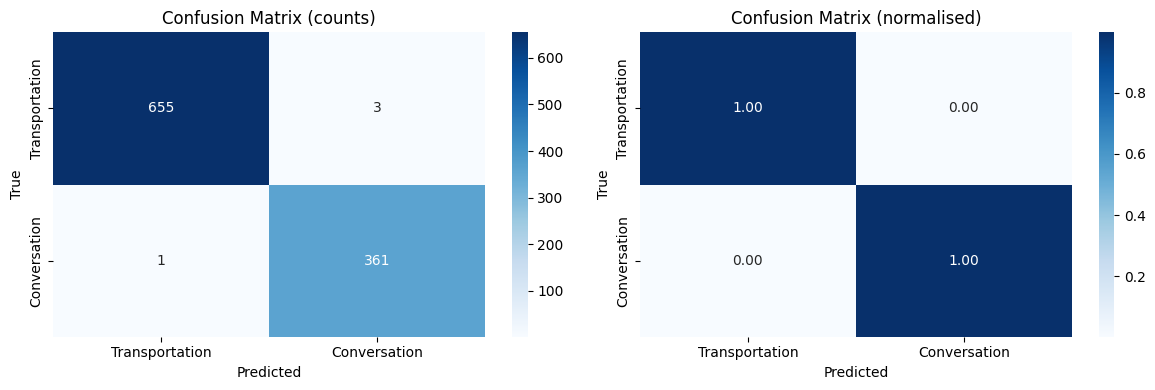

In [4]:
cm = confusion_matrix(y_test, y_pred)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=LABEL_NAMES, yticklabels=LABEL_NAMES, ax=axes[0])
axes[0].set_title('Confusion Matrix (counts)')
axes[0].set_ylabel('True'); axes[0].set_xlabel('Predicted')

sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=LABEL_NAMES, yticklabels=LABEL_NAMES, ax=axes[1])
axes[1].set_title('Confusion Matrix (normalised)')
axes[1].set_ylabel('True'); axes[1].set_xlabel('Predicted')

plt.tight_layout()
plt.show()

## 4. ROC curve

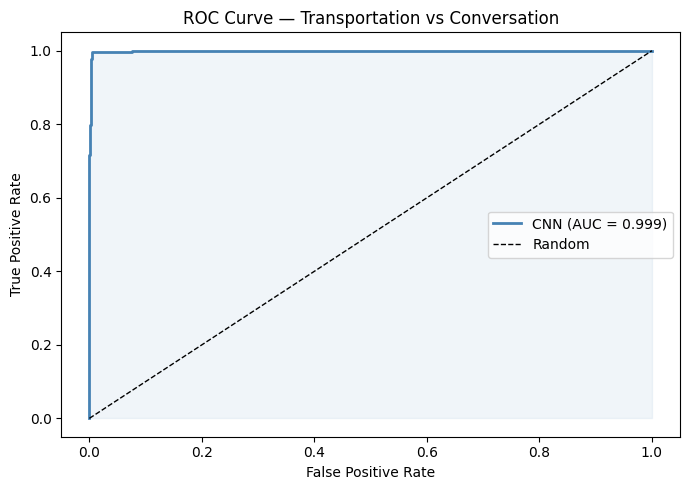

AUC: 0.9990


In [5]:
fpr, tpr, thresholds = roc_curve(y_test, y_proba[:, 1])
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, lw=2, color='steelblue', label=f'CNN (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], 'k--', lw=1, label='Random')
plt.fill_between(fpr, tpr, alpha=0.08, color='steelblue')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Transportation vs Conversation')
plt.legend()
plt.tight_layout()
plt.show()

print(f'AUC: {roc_auc:.4f}')

## 5. Confidence distribution

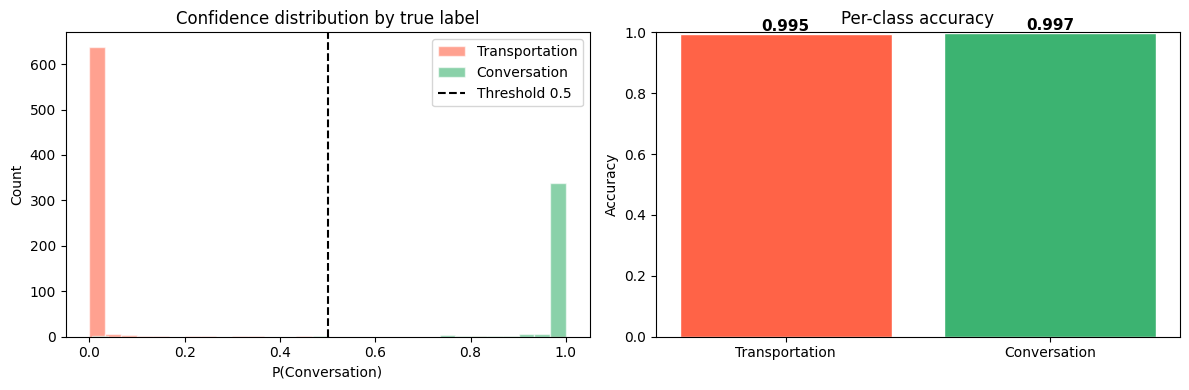

In [6]:
p_conv = y_proba[:, 1]   # P(conversation)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for label_id, name, color in [(0, 'Transportation', 'tomato'),
                                (1, 'Conversation', 'mediumseagreen')]:
    mask = y_test == label_id
    axes[0].hist(p_conv[mask], bins=30, alpha=0.6, color=color, label=name, edgecolor='white')

axes[0].axvline(0.5, color='black', linestyle='--', label='Threshold 0.5')
axes[0].set_xlabel('P(Conversation)')
axes[0].set_ylabel('Count')
axes[0].set_title('Confidence distribution by true label')
axes[0].legend()

# Per-class accuracy
per_class_acc = cm.diagonal() / cm.sum(axis=1)
bars = axes[1].bar(LABEL_NAMES, per_class_acc,
                   color=['tomato', 'mediumseagreen'], edgecolor='white')
axes[1].set_ylim(0, 1)
axes[1].set_title('Per-class accuracy')
axes[1].set_ylabel('Accuracy')
for bar, acc in zip(bars, per_class_acc):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f'{acc:.3f}', ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()